In [81]:
import pandas as pd
import numpy as np


In [82]:
df = pd.read_csv('../data/processed/engineered_sports_recovery_data.csv.csv')

In [83]:
df.columns

Index(['Unnamed: 0', 'heart_rate', 'body_temperature', 'hydration_level',
       'sleep_quality', 'recovery_score', 'stress_level', 'muscle_activity',
       'joint_angles', 'gait_speed', 'cadence', 'step_count', 'jump_height',
       'ground_reaction_force', 'range_of_motion', 'ambient_temperature',
       'humidity', 'altitude', 'playing_surface', 'training_intensity',
       'training_duration', 'training_load', 'fatigue_index',
       'injury_occurred', 'sport_type', 'gender', 'age', 'bmi',
       'recovery_status', 'recovery_status_str', 'recovery_time_hours'],
      dtype='object')

In [84]:
numerical_features = [
    'sleep_quality', 
    'training_intensity', 
    'training_load',
    'fatigue_index',
    'body_temperature', 
    'heart_rate', 
    'hydration_level',
    'muscle_activity',
    'ground_reaction_force',
    'ambient_temperature',
    
]

categorical_encoded = [
    'sport_type',
    'gender',
]

features = numerical_features + categorical_encoded
target = 'recovery_time_hours'

In [85]:
# 3. Create a subset containing only your raw selection + target
subset_features = features + [target]
df_subset = df[subset_features].copy()

In [86]:
df_final = pd.get_dummies(df_subset, columns=categorical_encoded, drop_first=True)

In [87]:
bool_cols = df_final.select_dtypes(include='bool').columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

In [88]:
df_final.dtypes

sleep_quality            float64
training_intensity       float64
training_load            float64
fatigue_index            float64
body_temperature         float64
heart_rate               float64
hydration_level          float64
muscle_activity          float64
ground_reaction_force    float64
ambient_temperature      float64
recovery_time_hours      float64
sport_type_Other           int64
sport_type_Soccer          int64
sport_type_Track           int64
gender_Male                int64
dtype: object

In [89]:
df_final.head()

,sleep_quality,training_intensity,training_load,fatigue_index,body_temperature,heart_rate,hydration_level,muscle_activity,ground_reaction_force,ambient_temperature,recovery_time_hours,sport_type_Other,sport_type_Soccer,sport_type_Track,gender_Male
0,5.466370,5.678475,548.417962,45.028687,37.048668,72.304051,76.481477,10.000000,1859.705455,17.603241,13.6,0,0,0,0
1,6.899090,6.411926,538.043815,42.254717,36.929536,40.000000,72.363938,310.293156,1852.051883,25.107144,13.9,0,0,0,0
2,9.574152,6.643242,647.784339,61.870056,36.334841,76.174609,100.000000,158.659094,1654.115836,27.894979,13.0,0,0,0,0
3,7.614297,6.194427,336.553431,50.268845,37.244474,100.543724,86.172473,107.079298,1727.371018,27.886378,13.4,0,0,0,0
4,5.631979,5.835804,496.076352,29.233575,36.510766,78.001235,83.195889,164.347133,1642.459351,22.812019,17.0,0,0,0,0


In [90]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 6. Separate features (X) and target (y)
X = df_final.drop(columns=[target])
y = df_final[target]

# Statsmodels requires an explicitly added constant (intercept)
X_with_constant = sm.add_constant(X)

In [91]:
# 7. Check Multicollinearity using Variance Inflation Factor (VIF)
def calculate_vif(features_df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(features_df.values, i)
        for i in range(features_df.shape[1])
    ]
    return vif_data.sort_values(by="VIF", ascending=False)

# Check VIF on features (including the constant)
vif_summary = calculate_vif(X_with_constant)
print("--- Variance Inflation Factor (VIF) Summary ---")
print(vif_summary)

--- Variance Inflation Factor (VIF) Summary ---
                  Feature          VIF
0                   const  4312.640694
3           training_load     4.683790
4           fatigue_index     2.960666
2      training_intensity     2.612915
1           sleep_quality     1.558517
12      sport_type_Soccer     1.514715
13       sport_type_Track     1.485788
7         hydration_level     1.395542
11       sport_type_Other     1.384326
6              heart_rate     1.249600
14            gender_Male     1.059079
5        body_temperature     1.050483
8         muscle_activity     1.001832
9   ground_reaction_force     1.001381
10    ambient_temperature     1.000423


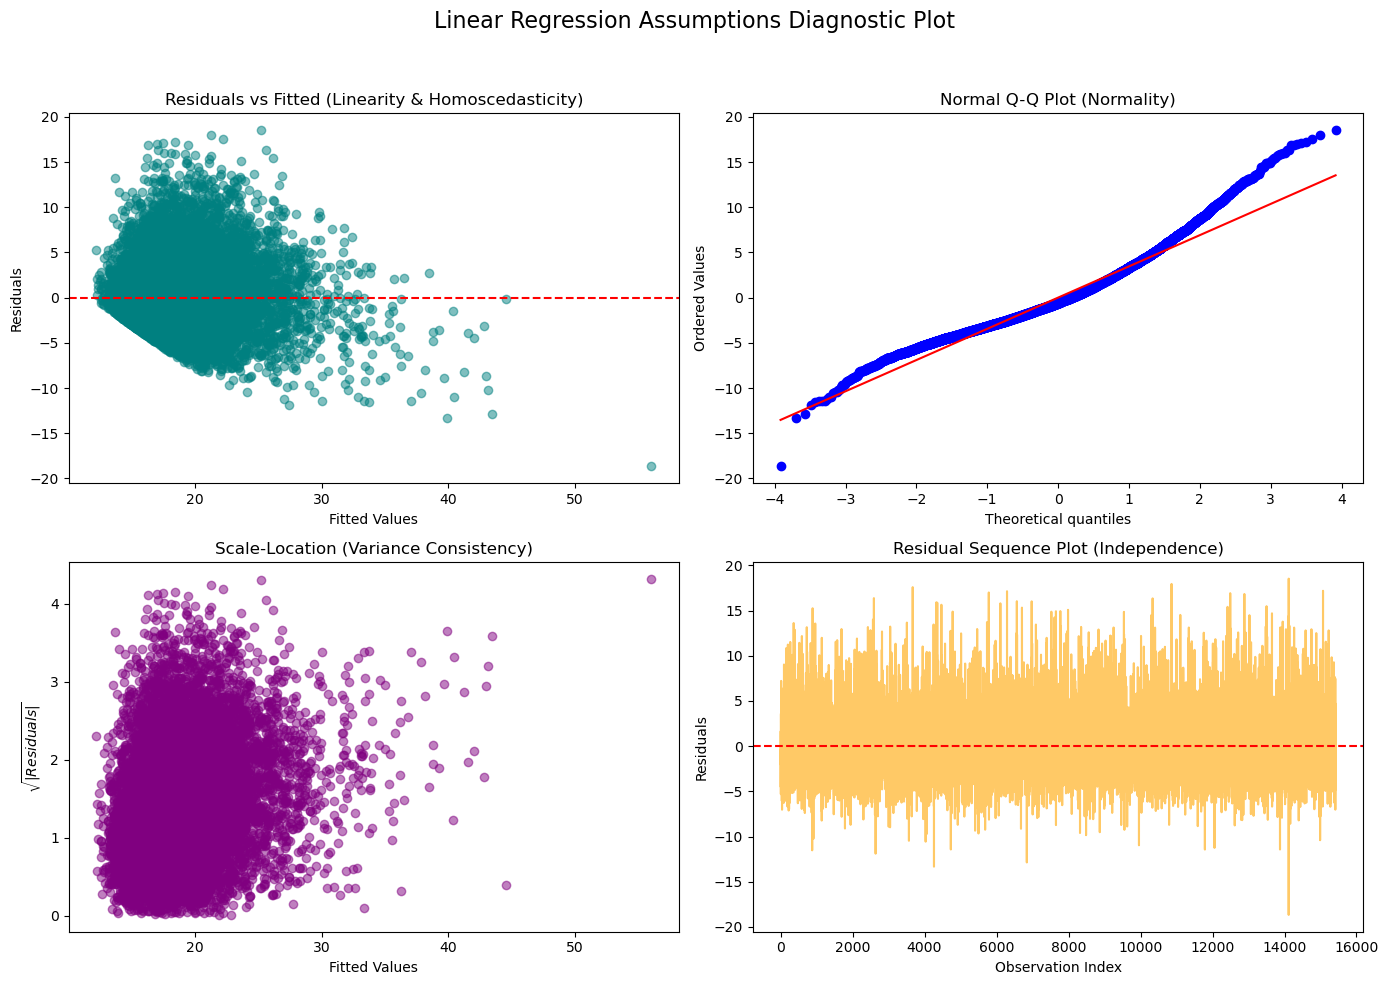

--- Statistical Tests for Assumptions ---
Breusch-Pagan Test p-value: 0.00000 (p > 0.05 implies Homoscedasticity)
Jarque-Bera Test p-value: 0.00000 (p > 0.05 implies Normality)
Durbin-Watson Statistic: 1.64 (Value near 2.0 implies Independence)


In [92]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.stats.api as sms

# Extract residuals and fitted values from your OLS model
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

# Set up a visualization dashboard for assumptions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Assumptions Diagnostic Plot', fontsize=16)

# 1. Linearity & Homoscedasticity (Residuals vs Fitted Plot)
axes[0, 0].scatter(fitted_values, residuals, alpha=0.5, color='teal')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted (Linearity & Homoscedasticity)')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# 2. Normality of Residuals (Q-Q Plot)
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot (Normality)')

# 3. Homoscedasticity Scale-Location Plot
sqrt_abs_resid = np.sqrt(np.abs(residuals))
axes[1, 0].scatter(fitted_values, sqrt_abs_resid, alpha=0.5, color='purple')
axes[1, 0].set_title('Scale-Location (Variance Consistency)')
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('$\sqrt{|Residuals|}$')

# 4. Independence of Errors (Residual Sequence Plot)
axes[1, 1].plot(residuals.index, residuals, alpha=0.6, color='orange')
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('Residual Sequence Plot (Independence)')
axes[1, 1].set_xlabel('Observation Index')
axes[1, 1].set_ylabel('Residuals')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- Statistical Tests ---
print("--- Statistical Tests for Assumptions ---")

# A. Breusch-Pagan Test for Homoscedasticity
bp_test = sms.het_breuschpagan(residuals, X_with_constant)
print(f"Breusch-Pagan Test p-value: {bp_test[1]:.5f} (p > 0.05 implies Homoscedasticity)")

# B. Jarque-Bera Test for Normality
jb_test = stats.jarque_bera(residuals)
print(f"Jarque-Bera Test p-value: {jb_test[1]:.5f} (p > 0.05 implies Normality)")

# C. Durbin-Watson Test for Autocorrelation (Independence)
dw_score = sms.durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_score:.2f} (Value near 2.0 implies Independence)")

In [93]:
# 8. Fit the initial OLS Regression Model
ols_model = sm.OLS(y, X_with_constant).fit()

# Display the model summary
print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     recovery_time_hours   R-squared:                       0.605
Model:                             OLS   Adj. R-squared:                  0.605
Method:                  Least Squares   F-statistic:                     1688.
Date:                 Fri, 10 Jul 2026   Prob (F-statistic):               0.00
Time:                         00:23:06   Log-Likelihood:                -38762.
No. Observations:                15420   AIC:                         7.755e+04
Df Residuals:                    15405   BIC:                         7.767e+04
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

In [94]:
# 5. Export to the final CSV file
output_filename = "../data/processed/final_dataset.csv"
df_final.to_csv(output_filename, index=False)